# Panel App: Target Audit

A multi-stage application for auditing the targets within our region orthophoto.

- Upload region image
- Select samples of region
- Set parameters for CV search
    - Visualize parameters
- Run parameters on full orthophoto
    - View output
- Generate binary mask
- Audit detected targets on map
- Save targets to local geoJSON



In [1]:
import param
import panel as pn

pipeline = pn.pipeline.Pipeline()

In [2]:
import sys
import geopandas as gpd
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [3]:
region_crs = 32613 # Use this everywhere for consistency
visualization_crs = 4326 # Use this when we need leaflet visualizations

# region_image_path = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'
region_image_path = '../tile_server/input/IGNORE_reprojected_region.tif'

region_contour_geojson = '../input/interactive_proto/region_contour.geojson'
micro_routes_filename = '../input/interactive_proto/micro_routes.geojson'
targets_plants_filename = '../input/interactive_proto/targets.geojson'
depots_filename = '../input/interactive_proto/depot_points.geojson'


## Upload Input Files

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
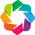

In [4]:
import param
import panel as pn
import geopandas as gpd
from io import BytesIO
import json
from PIL import Image
import geoviews as gv

gv.extension('bokeh')
pn.extension('filedropper')

class UploadRegionFiles(param.Parameterized):
    # Parameters for tracking uploaded files
    region_image_upload = param.Parameter(default=None)
    region_geojson_upload = param.Parameter(default=None)
    
    region_image_upload_name = param.Parameter(default=None)
    region_geojson_upload_name = param.Parameter(default=None)

    # FileDropper widgets

    # Accepted filetypes bug for this widget: https://github.com/holoviz/panel/issues/7153
    # accepted_filetypes=["allowed/geojson", ".geojson"],
    # Unable to handle our large geoTiff images
    image_dropper = pn.widgets.FileDropper(height=100, max_file_size ="500MB", chunk_size=30000000)
    geojson_dropper = pn.widgets.FileDropper(height=100, max_file_size ="100MB")

    def __init__(self, **params):
        super().__init__(**params)

        # Link FileDropper outputs to parameters
        self.image_dropper.param.watch(self._update_region_image, "value")
        self.geojson_dropper.param.watch(self._update_region_geojson, "value")

    # Update methods for parameters
    def _update_region_image(self, event):
            # Upate for all events, including removal of file
            self.region_image_upload = event.new
            self.get_region_image() # Update name & contents when possible

    def _update_region_geojson(self, event):
        self.region_geojson_upload = event.new
        self.get_region_geojson() # Update name & contents when event triggered

    def get_region_image(self):
        if self.region_image_upload:
            image_upload_dict = self.region_image_upload # Stays as dict of files
            first_file_name = list(image_upload_dict.keys())[0] # Dict of file names:bytes
            image_stream  = BytesIO(image_upload_dict[first_file_name]) # Bytes to Stream
            region_image = Image.open(image_stream)  # Stream to PIL image
            self.region_image_upload_name = first_file_name
            return region_image
        else:
            self.region_image_upload_name = None
            return None

    def get_region_geojson(self):
        if self.region_geojson_upload:
            geojson_upload_dict = self.region_geojson_upload # Dict of files
            first_file_name = list(geojson_upload_dict.keys())[0] # Dict of file names:bytes
            file_bytes_string = geojson_upload_dict[first_file_name].decode("utf-8") # Bytes to string
            region_geojson = json.loads(file_bytes_string)  # String to JSON dict
            
            self.region_geojson_upload_name = first_file_name
            return region_geojson
        else:
            self.region_geojson_upload_name = None # Remember to reset when deleted
            return None

    def view_image(self):
        if self.region_image_upload:
            try:
                image_data = self.get_region_image()
                return pn.pane.Image(image_data, height=500, width=500)
            except Exception as e:
                return f"Error displaying image: {e}"
        else:
            return "No image uploaded."

    # A method to display the GeoJSON region outline
    def view_geojson(self):
        if self.region_geojson_upload:
            try:
                region_geojson = self.get_region_geojson()
                json_pane = pn.pane.JSON(region_geojson, depth=2, name="Uploaded GeoJSON")

                gdf = gpd.GeoDataFrame.from_features(region_geojson["features"])
                gv_geojson = gv.Polygons(gdf, vdims=["name"] if "name" in gdf.columns else None).opts(
                    fill_alpha=0.5,
                    line_width=2,
                    color="blue",
                    tools=["hover"],
                    active_tools=["wheel_zoom"],
                    width=600,
                    height=400,
                    title="Region Outline Visualization"
                )

                geojson_row = pn.Row(json_pane, gv_geojson)

                return geojson_row
            except Exception as e:
                return f"Error processing GeoJSON: {e}"
        else:
            return "No GeoJSON uploaded."

    # Panel layout combining file droppers and visualizations
    def view(self):
        return pn.Column(
            pn.Row(
                pn.Column("**Drop Region Image Here**", self.image_dropper),
                pn.Column("**Drop GeoJSON Here**", self.geojson_dropper),
            ),
            pn.Row(
                pn.Column("**Uploaded Region Image**", self.view_image),
                pn.Column("**Uploaded GeoJSON Outline**", self.view_geojson),
            ),
        )


# # Run the app
# target_audit_app = UploadRegionFiles()
# target_audit_app.panel().servable()

# target_audit_app.view().show()

In [5]:
import param

class StageUpload(param.Parameterized):
    
    def __init__(self, **params):
        super().__init__(**params)
        self._add_upload_widgets()

    @param.output()
    def output(self):
        region_orthophoto = self.upload_widgets.get_region_image()
        region_geojson = self.upload_widgets.get_region_geojson()
        return region_orthophoto, region_geojson
    
    def _add_upload_widgets(self):
        self.upload_widgets = UploadRegionFiles()

    def panel(self):
        return self.upload_widgets.view().servable()

## Perform CV Search
- Set parameters for CV seach
- Perform on uploaded image

In [27]:
from skimage.exposure import equalize_adapthist
from skimage.filters import threshold_otsu
from skimage.morphology import opening, closing, disk
import cv2
import numpy as np

from plant_search.vegetation_indices import normalize_rgb, calculate_exg

import param
import panel as pn

class ProcessingTechnique(param.Parameterized):
    def apply(self, image):
        raise NotImplementedError("Each technique must implement the `apply` method.")


class VegetationIndex(param.Parameterized):
    vegetation_index_enabled = param.Boolean(default=True, doc="Choose to enable vegetation index")
    selected_vegetation_index = param.Selector(objects=["exg"])

    def __init__(self, **params):
        super().__init__(**params)

    def apply(self, image):
        if self.vegetation_index_enabled:
            exg = calculate_exg(*normalize_rgb(image))
            exg_normalized = (exg - np.min(exg)) / (np.max(exg) - np.min(exg))  # Normalize to [0, 1]
            exg_uint8 = (exg_normalized * 255).astype(np.uint8)
            return exg_uint8
        else:
                return image # Pass along without updating

    def view(self):
        panel_column = pn.Column(
            "Vegetation Index",
            self.param
        )
        return panel_column


class Smoothing(ProcessingTechnique):
    smoothing_enabled = param.Boolean(default=True, doc="Choose to enable bilinear filtering")
    smoothing_diameter = param.Integer(default=9, bounds=(3, 20), doc="Diameter of each pixel neighborhood used during filtering.")
    smoothing_sigma_color = param.Number(default=50, bounds=(20,70), doc="Controls how much influence the color difference between pixels has on the filtering")
    smoothing_sigma_spatial = param.Number(default=15, doc="Controls the influence of the spatial distance between pixels.")

    def apply(self, image):
        if self.smoothing_enabled:
            bilateral_smoothed_img = cv2.bilateralFilter(
                image , d=self.smoothing_diameter, 
                sigmaColor=self.smoothing_sigma_color, 
                sigmaSpace=self.smoothing_sigma_spatial
            )
            bilateral_smoothed_img = bilateral_smoothed_img / 255.0  # Scale back to [0, 1]
            return bilateral_smoothed_img
        else:
            return image # Pass along without updating

    def view(self):
        panel_column = pn.Column(
            "Image Smoothing",
            self.param
        )
        return panel_column


class MorphologicalRefinement(ProcessingTechnique):
    morphological_enabled = param.Boolean(default=True, doc="Choose to enable morphological refinement")
    morphological_disk_size = param.Integer(default=7, doc="Radius of structuring element for contour adjustment")

    def apply(self, image):
        if self.morphological_enabled:
            selem = disk(7)  # Structuring element
            morph_img = closing(opening(image, selem), selem)
            return morph_img
        else:
            return image # Pass along without updating
        
    def view(self):
        panel_column = pn.Column(
            "Morphological Refinement",
            self.param
        )
        return panel_column


class TargetSearch(param.Parameterized):

    input_image = param.Parameter(default=None, doc="Input orthophoto to search")
    techniques = param.List(default=[])

    # contrast_enhance_enabled = param.Boolean(default=False, doc="Choose to enable contrast enhancement")
    # contrast_clip_limit = param.Number(default=0.02, doc="Defines the maximum allowed height of the histogram bins in each tile")


    def __init__(self, **params):
        super().__init__(**params)
        # self._add_upload_widgets()
    
    # @param.output()
    def search_targets(self):
        image = self.input_image
        for technique in self.techniques:
            image = technique.apply(image)
        return image

    def view(self):
        # panels = [technique.view() for technique in self.techniques]
        tabs = pn.Tabs(
            *[  (technique.__class__.__name__, technique.view())
                for technique in self.techniques
            ])
        target_panel = pn.Column(
            pn.Row("**Find targets from image**"),
            tabs,
            self.param
        )
        return target_panel
    
    

In [ ]:
import param

class StageSearch(param.Parameterized):
    
    def __init__(self, **params):
        super().__init__(**params)
        self._add_search_widgets()

    @param.output()
    def output(self):
        return
    
    def _add_search_widgets(self):
        self.search_widgets = TargetSearch()

    def panel(self):
        return self.search_widgets.view().servable()
    

# Manually run this stage
from plant_search.load_image import load_image, plot_image

image, transform, bounds, crs = load_image(region_image_path)
# if image is not None:
#     plot_image(image, "Original Image")


veg_index = VegetationIndex()
smoothing = Smoothing()
morphological = MorphologicalRefinement()

search = TargetSearch(
    input_image=image, 
    techniques=[veg_index, smoothing, morphological]
)
search.view().show()



Image CRS - EPSG:4326
Launching server at http://localhost:64039


## Audit Targets
- Manually deselect targets missed by the algorithm

In [8]:
from ipyleaflet import (
    Map, GeoJSON, TileLayer, GeoData, 
    WidgetControl, LayersControl, ScaleControl, 
    GeomanDrawControl, FullScreenControl, ZoomControl
)
from panel.widgets import Button
import ipywidgets
import param
import panel as pn
import pandas as pd
import json
from shapely.geometry import shape

class MapView(param.Parameterized):
    # region_image_path = param.String(doc="Path to the orthophoto image")
    region_geojson_path = param.String(doc="Path to the GeoJSON file defining the region")
    targets_gdf = param.Parameter(default=None, doc="GeoPandas DF of potential targets")

    def __init__(self, **params):
        super().__init__(**params)
        self.map = None
        self.removed_targets_gdf = gpd.GeoDataFrame(columns=self.targets_gdf.columns, geometry='geometry')
        # self.sample_boxes_gdf = None
        # self.combined_gdf = None
        self.drawn_rectangles = []
        self.region_data = None
        self._initialize_region_data()
        self._initialize_map()

    def _initialize_region_data(self):
        with open(self.region_geojson_path, "r") as f:
            self.region_data = json.load(f)
        region_geometry = shape(self.region_data['features'][0]['geometry'])
        self.region_center = region_geometry.centroid

    def _initialize_map(self):
        self.map = Map(center=(self.region_center.y, self.region_center.x), zoom=16, scroll_wheel_zoom=True)

        # self.tile_layer = TileLayer(
        #     url="http://localhost:8000/{z}/{x}/{y}.png",
        #     min_zoom=15, max_zoom=22,
        #     name="Region Image"
        # )
        # self.map.add(self.tile_layer)

        self._add_region_outline_layer()
        self._add_targets_layer()
        self._add_removed_targets_layer()
        self._add_map_controls()
        self._add_draw_control()
        self._add_mass_remove_button()

    def _add_region_outline_layer(self):
        region_layer = GeoJSON(
            data=self.region_data, 
            style={'color': 'blue', 'fillOpacity': 0.05, 'weight': 2},
            name=self.region_data['name'])
        self.map.add(region_layer) # Add the region border to the map

    def _add_targets_layer(self):
        self.targets_layer = GeoData(
            geo_dataframe=self.targets_gdf,
            style={'color': 'black', 'radius':6, 'fillColor': 'blue', 'opacity':0.5, 'weight':1, 'fillOpacity':0.3},
            hover_style={'fillColor': 'blue' , 'fillOpacity': 0.2},
            point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
            draggable=True,
            name="Identified targets"
            )
        
        def on_click_target(event, feature, properties, id):
            # Move the clicked point to the removed targets layer
            target_id = properties['target_id']
            clicked_point = self.targets_gdf[self.targets_gdf['target_id'] == target_id]
            # Remove from targets_gdf
            self.targets_gdf = self.targets_gdf[self.targets_gdf['target_id'] != target_id]
            self.targets_layer.geo_dataframe = self.targets_gdf
            # Add to removed_targets_gdf
            self.removed_targets_gdf = pd.concat([self.removed_targets_gdf, clicked_point])
            self.removed_targets_layer.geo_dataframe = self.removed_targets_gdf

        self.targets_layer.on_click(on_click_target)
        self.map.add(self.targets_layer)

    def _add_removed_targets_layer(self):
        self.removed_targets_layer = GeoData(
            geo_dataframe=self.removed_targets_gdf,
            style={'color': 'black', 'radius':6, 'fillColor': 'red', 'opacity':0.5, 'weight':1, 'fillOpacity':0.3},
            hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
            point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
            draggable=True,
            name="Removed targets"
            )
        
        def on_click_removed_target(event, feature, properties, id):
            target_id = properties['target_id']
            clicked_point = self.removed_targets_gdf[self.removed_targets_gdf['target_id'] == target_id]

            self.removed_targets_gdf = self.removed_targets_gdf[self.removed_targets_gdf['target_id'] != target_id]
            self.removed_targets_layer.geo_dataframe = self.removed_targets_gdf # Remove from removed_targets_gdf
            
            self.targets_gdf = pd.concat([self.targets_gdf, clicked_point]) # Add back to targets_gdf
            self.targets_layer.geo_dataframe = self.targets_gdf

        self.removed_targets_layer.on_click(on_click_removed_target)
        self.map.add(self.removed_targets_layer)

    def _add_draw_control(self):
        self.draw_control = GeomanDrawControl()
        
        self.draw_control.circlemarker = {}
        self.draw_control.polygon = {}
        self.draw_control.polyline = {}
        self.draw_control.rectangle = {"pathOptions": {"weight": 2, "color": "green", "fillOpacity": 0.1}}
        
        self.draw_control.rotate = False
        self.draw_control.cut = False
        self.draw_control.edit = False
        self.draw_control.drag = False # Does not maintain state 
        self.draw_control.remove = False # Swap GDFs, don't remove

        self.map.add(self.draw_control)

    def _add_map_controls(self):
        # self.map.add(ZoomControl(position='bottomleft'))
        self.map.add(FullScreenControl(position='topleft'))
        self.map.add(LayersControl(position="topright"))
        self.map.add(ScaleControl(position="bottomleft"))

    def _add_mass_remove_button(self):
        self.button = ipywidgets.Button(
            description="Process Rectangles", 
            tooltip="Remove all targets in selections",  # Tooltip text
            icon="rectangle-xmark"
        )

        def process_rectangles(event):
            if not self.draw_control.data or not isinstance(self.draw_control.data, list):
                print("no drawn")
                return # No drawn geometries
            drawn_geometries = [
                shape(item["geometry"])
                for item in self.draw_control.data # Extract valid geometries from draw control data
                if "geometry" in item
            ]
            if not drawn_geometries:
                print("no valid drawn")
                return # Exit early if no valid geometries are found
            
            all_selections = gpd.GeoSeries(drawn_geometries).union_all() # Combine selections
            points_in_selections = self.targets_gdf[self.targets_gdf.geometry.within(all_selections)]
            if points_in_selections.empty:
                return # No points found within the drawn rectangles

            self.removed_targets_gdf = pd.concat([self.removed_targets_gdf, points_in_selections])
            self.targets_gdf = self.targets_gdf[~self.targets_gdf.index.isin(points_in_selections.index)]

            self.targets_layer.geo_dataframe = self.targets_gdf # Update the layers
            self.removed_targets_layer.geo_dataframe = self.removed_targets_gdf
            self.draw_control.clear() # Clear the drawn rectangles
    
        self.button.on_click(process_rectangles)
        self.map.add(WidgetControl(widget=self.button, position='bottomright'))

In [9]:
import geopandas as gpd
import panel as pn
from io import BytesIO

class DownloadGeoJSON(param.Parameterized):
    # Parameter to hold the GeoDataFrame
    source_gdf = param.ClassSelector(class_=gpd.GeoDataFrame, default=None, allow_None=True)
    filename = param.String(default="output.geojson")
    button_type = param.String(default="primary")
    name = param.String(default="Download")

    def get_geojson_file(self):
        """
        Convert the current GeoDataFrame (source_gdf) to a GeoJSON string for download.
        """
        if self.source_gdf is None:
            print("No GeoDataFrame is set!")
            return BytesIO()  # Return an empty file
        bio = BytesIO()
        self.source_gdf.to_file(bio, driver="GeoJSON")
        bio.seek(0)
        return bio

    @param.depends("source_gdf", "filename", "button_type", "name")
    def download_widget(self):
        """
        Return a FileDownload widget based on the current state of the parameters.
        """
        return pn.widgets.FileDownload(
            callback=lambda: self.get_geojson_file(),
            filename=self.filename,
            button_type=self.button_type,
            name=self.name
        )

In [10]:
import param

class StageAudit(param.Parameterized):
    region_geojson_path = param.String(doc="Path to the GeoJSON file defining the region")
    targets_gdf = param.Parameter(default=None, doc="GeoPandas DF of potential targets")

    @param.output() # TBD best param type for geoJSON/GDFs
    def output(self):
        return self.map_view.targets_gdf, self.map_view.removed_targets_gdf

    def __init__(self, **params):
        super().__init__(**params)
        self._add_map()
        self._add_download_widgets()

    def _add_map(self):
        targets_points_gdf = self.targets_gdf[['geometry','target_id']] # remove confusing cols
        self.map_view = MapView(
            region_geojson_path = region_contour_geojson,
            targets_gdf = targets_points_gdf
        )

    def _add_download_widgets(self):
        download_targets = DownloadGeoJSON(
            source_gdf=self.map_view.targets_gdf,
            filename="targets.geojson",
            button_type="primary",
            name="Download Targets"
        )
        download_removed_targets = DownloadGeoJSON(
            source_gdf=self.map_view.removed_targets_gdf,
            filename="removed_targets.geojson",
            button_type="warning",
            name="Download Removed Targets"
        )
        self.download_widgets = pn.Column(
            "# Parameterized GeoJSON Downloads",
            pn.Row(
                download_targets.download_widget,
                download_removed_targets.download_widget,
                width=400
            )
        )
        
    def panel(self):
        map_panel = pn.panel(self.map_view.map)
        layout = pn.Column(
            map_panel,
            self.download_widgets
        )
        return layout
    

In [11]:
import geopandas as gpd

pn.extension()

# Convert from file to correct stage input type (gdf)
targets_gdf = gpd.read_file(targets_plants_filename)

audit_stage = StageAudit(
    targets_gdf=targets_gdf,
    region_geojson_path=region_contour_geojson
)

audit_stage.panel().show()

# map_panel = pn.pane.IPyWidget(map_view.map)
# map_panel = pn.panel(map_view.map).servable();
# map_panel = pn.panel(map_view.map)

# pn.template.FastListTemplate(
#     site="Panel",
#     title="Getting Started App",
#     sidebar=[dummy_button],
#     main=[layout],
# ).servable(); # The ; is needed in the notebook to not display the template. Its not needed in a script

Launching server at http://localhost:62920


## Complete Pipeline Setup
Add our initialized stages to the pipeline.

In [12]:

pipeline.add_stage('Upload', StageUpload)
pipeline.add_stage('Search', StageSearch)
pipeline.add_stage('Audit', StageAudit)

pipeline.show()

Launching server at http://localhost:62921
